In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

plt.style.use("default")  

In [3]:

folder_path = "crop/"  

csv_files = glob.glob(folder_path + "*.csv")
print("Files found:", csv_files)

# Combine all CSVs
data = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
print("Combined dataset shape:", data.shape)

Files found: ['crop\\2025.csv', 'crop\\2026.csv']
Combined dataset shape: (5984442, 11)


In [5]:
data.head()


,State,District,Market,Commodity,Variety,Grade,Arrival_Date,Min_Price,Max_Price,Modal_Price,Commodity_Code
0,Andhra Pradesh,Chittor,Chittoor,Gur (Jaggery),NO 2,FAQ,2025-01-01,3200.0,3500.0,3500.0,74
1,Tamil Nadu,The Nilgiris,Gudalur (Uzhavar Sandhai ),Garlic,Average,Local,2025-01-01,28000.0,30000.0,30000.0,25
2,Tamil Nadu,The Nilgiris,Gudalur (Uzhavar Sandhai ),Ginger (Green),Green Ginger,Local,2025-01-01,7000.0,8000.0,8000.0,103
3,Tamil Nadu,The Nilgiris,Gudalur (Uzhavar Sandhai ),Green Chilli,Green Chilly,Local,2025-01-01,4500.0,5000.0,5000.0,87
4,Tamil Nadu,The Nilgiris,Gudalur (Uzhavar Sandhai ),Mint (Pudina),Mint (Pudina),Local,2025-01-01,4500.0,5000.0,5000.0,360


In [6]:
data.columns

Index(['State', 'District', 'Market', 'Commodity', 'Variety', 'Grade',
       'Arrival_Date', 'Min_Price', 'Max_Price', 'Modal_Price',
       'Commodity_Code'],
      dtype='str')

In [10]:
data['Arrival_Date'] 
pd.to_datetime(data['Arrival_Date'], errors='coerce')
data = data.sort_values('Arrival_Date')
print(data['Arrival_Date'].min(), data['Arrival_Date'].max())

2025-01-01 2026-01-26


In [11]:
data.info()

<class 'pandas.DataFrame'>
Index: 5984442 entries, 0 to 5984441
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   State           str    
 1   District        str    
 2   Market          str    
 3   Commodity       str    
 4   Variety         str    
 5   Grade           str    
 6   Arrival_Date    str    
 7   Min_Price       float64
 8   Max_Price       float64
 9   Modal_Price     float64
 10  Commodity_Code  int64  
dtypes: float64(3), int64(1), str(7)
memory usage: 547.9 MB


In [12]:
data.isnull().sum()

State             0
District          0
Market            0
Commodity         0
Variety           0
Grade             0
Arrival_Date      0
Min_Price         0
Max_Price         0
Modal_Price       0
Commodity_Code    0
dtype: int64

In [13]:
data['Modal_Price'].describe()

count    5.984442e+06
mean     4.481359e+03
std      6.596095e+03
min      5.000000e-02
25%      2.040000e+03
50%      3.400000e+03
75%      5.500000e+03
max      4.000000e+06
Name: Modal_Price, dtype: float64

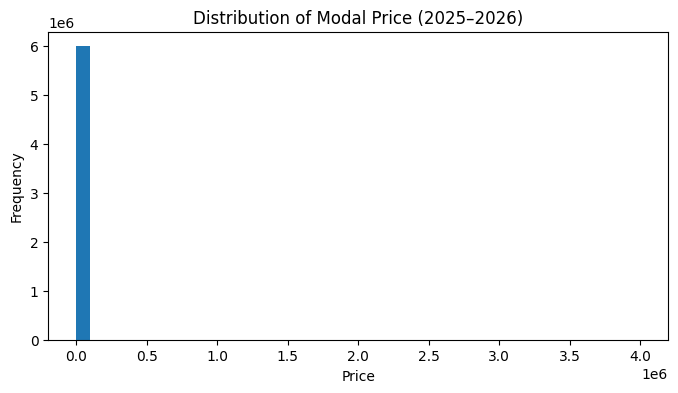

In [14]:
plt.figure(figsize=(8,4))
plt.hist(data['Modal_Price'], bins=40)
plt.title("Distribution of Modal Price (2025–2026)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [15]:
data['Modal_Price'].dtype

dtype('float64')

In [ ]:
print(data['Modal_Price'].min())
print(data['Modal_Price'].max())
print(data['Modal_Price'].mean())
print(data['Modal_Price'].unique()[:20])  # first 20 unique values


print(data['Modal_Price'].value_counts().head(10))

0.05
4000000.0
4481.359241730085
[ 3500.    1100.    1500.    2600.    1000.    9500.   15500.   12500.
 15000.   11500.    1000.05  4000.    2500.     700.    2200.    1667.5
   900.    2000.    3700.    3800.  ]
Modal_Price
3000.0    312798
4000.0    303411
5000.0    221599
2000.0    211296
6000.0    201494
2500.0    200514
3500.0    170500
7000.0    120404
1500.0    118197
4500.0    110319
Name: count, dtype: int64


In [19]:
top_crops = data['Commodity'].value_counts().head(10)
print("Top 10 crops:\n", top_crops)

Top 10 crops:
 Commodity
Onion                     226844
Tomato                    216087
Potato                    209354
Wheat                     193384
Brinjal                   190408
Banana                    181653
Green Chilli              180539
Bhindi (Ladies Finger)    151879
Bottle gourd              140885
Cabbage                   138396
Name: count, dtype: int64


In [25]:
df=data.copy()

In [26]:
# Strip spaces and convert to datetime safely
df['Arrival_Date'] = pd.to_datetime(df['Arrival_Date'].astype(str).str.strip(), errors='coerce')

# Check for invalid dates
invalid_dates = df['Arrival_Date'].isna().sum()
print("Number of invalid dates:", invalid_dates)

Number of invalid dates: 0


In [27]:
df = df[df['Arrival_Date'].dt.year.isin([2025, 2026])]
print("Shape after filtering:", df.shape)

Shape after filtering: (5984442, 11)


In [28]:
# Ensure numeric
df['Modal_Price'] = pd.to_numeric(df['Modal_Price'], errors='coerce')
print(df['Modal_Price'].describe())

count    5.984442e+06
mean     4.481359e+03
std      6.596095e+03
min      5.000000e-02
25%      2.040000e+03
50%      3.400000e+03
75%      5.500000e+03
max      4.000000e+06
Name: Modal_Price, dtype: float64


In [29]:
print(df.isnull().values.any())

False


In [31]:
df['Year']=df['Arrival_Date'].dt.year
print(df[['Arrival_Date','Year']].head())

      Arrival_Date  Year
0       2025-01-01  2025
10231   2025-01-01  2025
10232   2025-01-01  2025
10233   2025-01-01  2025
10234   2025-01-01  2025


In [32]:
yearly_avg = df.groupby('Year')['Modal_Price'].mean()
print(yearly_avg)

Year
2025    4479.058924
2026    4568.598726
Name: Modal_Price, dtype: float64


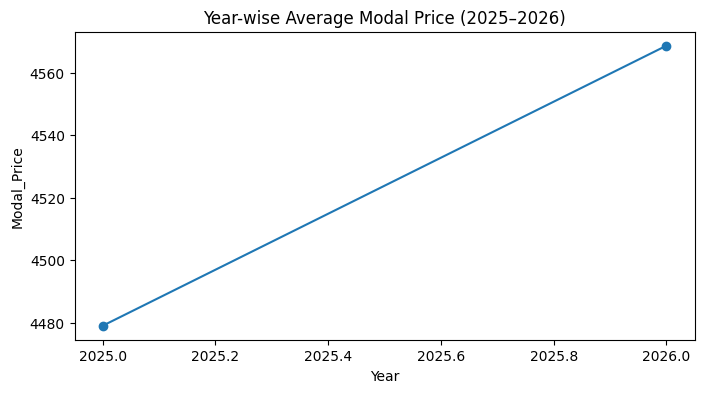

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(yearly_avg.index, yearly_avg.values, marker='o')
plt.title("Year-wise Average Modal Price (2025–2026)")
plt.xlabel("Year")
plt.ylabel("Modal_Price")
plt.show()

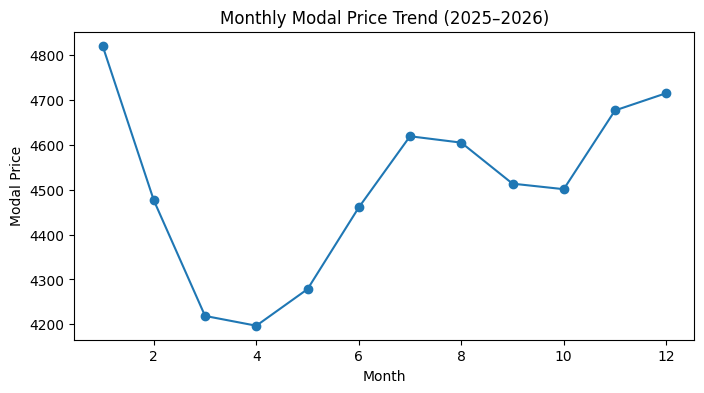

In [34]:
df['month'] = df['Arrival_Date'].dt.month
monthly_avg = df.groupby('month')['Modal_Price'].mean()

plt.figure(figsize=(8,4))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o')
plt.title("Monthly Modal Price Trend (2025–2026)")
plt.xlabel("Month")
plt.ylabel("Modal Price")
plt.show()

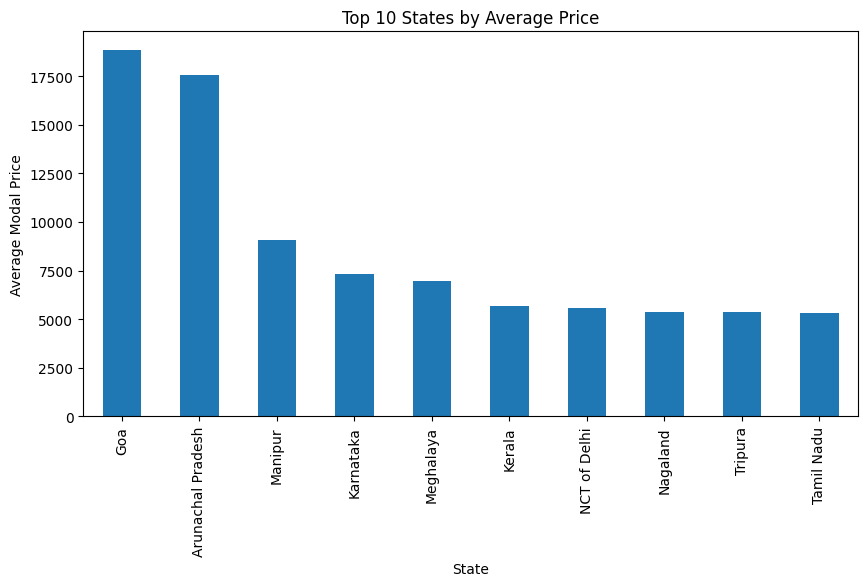

In [35]:
state_avg = df.groupby('State')['Modal_Price'].mean().sort_values(ascending=False)
state_avg.head(10).plot(kind='bar', figsize=(10,5), title="Top 10 States by Average Price")
plt.xlabel("State")
plt.ylabel("Average Modal Price")
plt.show()

In [38]:
df['price_spread'] = df['Max_Price'] - df['Min_Price']
df['price_spread'].describe()

count    5.984442e+06
mean     6.969485e+02
std      2.245846e+03
min     -6.400000e+04
25%      1.000000e+02
50%      4.000000e+02
75%      7.100000e+02
max      8.484000e+05
Name: price_spread, dtype: float64

In [40]:
df.to_csv("crop_25_26_combined.csv",index=False)

In [3]:
print("hi")

hi
